<a href="https://colab.research.google.com/github/Rahneesh/cbg-predictive-analytics/blob/main/CBG___Try_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# Imports

import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [62]:
input_data=pd.read_excel('/content/drive/MyDrive/Entri - Data Science with Gen AI - Assignments/#3: Main Project/CBG _ real Data.xlsx')
display(input_data.head())
display(input_data.describe())

,Serial Number,Date,Feed TPD - PS,PS - TS %,PS - VS %,Feed TPD - PMC,PMC - TS %,PMC - VS %,Feed TPD - CD,CD - TS %,...,Rolling_Avg_VS_7D,Hydrolyser Temp - Avg,Digester Temp - Avg,HRT,VFA,OLR,Raw biogas production (Nm³/day),Slurry fed into the digester (Nm3),Slurry fed out of the digester (Nm3),CBG Production (kg/day)
0,1,2035-01-01,30.6,88.4,83.7,30.6,88.4,83.7,36,30.8,...,NaN,NaN,NaN,1.81,10552.1,37.0,18967.0,760.0,513.0,6.169
1,2,2035-01-02,13.5,89.5,85.0,13.5,89.5,85.0,40,38.8,...,NaN,NaN,NaN,2.81,10350.8,21.0,20608.0,810.0,730.0,6.889
2,3,2035-01-03,65.4,81.3,72.6,65.4,81.3,72.6,43,39.9,...,NaN,NaN,NaN,3.70,9560.4,19.0,20395.0,885.0,622.0,6.907
3,4,2035-01-04,23.5,85.9,76.3,23.5,85.9,76.3,21,36.5,...,NaN,NaN,NaN,1.96,14206.2,32.0,21721.0,890.0,512.0,6.808
4,5,2035-01-05,22.3,76.3,70.4,22.3,76.3,70.4,0,36.5,...,NaN,NaN,NaN,2.30,9078.0,25.0,21032.0,741.0,692.0,7.164


,Serial Number,Date,Feed TPD - PS,PS - TS %,PS - VS %,Feed TPD - PMC,PMC - TS %,PMC - VS %,Feed TPD - CD,CD - TS %,...,Rolling_Avg_VS_7D,Hydrolyser Temp - Avg,Digester Temp - Avg,HRT,VFA,OLR,Raw biogas production (Nm³/day),Slurry fed into the digester (Nm3),Slurry fed out of the digester (Nm3),CBG Production (kg/day)
count,646.000000,646,646.000000,646.000000,646.000000,646.000000,646.000000,646.000000,646.000000,646.000000,...,640.000000,583.000000,585.000000,646.000000,316.000000,646.000000,646.000000,645.000000,541.000000,646.000000
mean,323.500000,2035-11-19 12:00:00,66.536687,86.837910,80.426146,66.536687,86.837910,80.426146,28.407121,26.829257,...,101.310938,48.701383,52.661746,5.297353,2647.889873,19.713804,19249.809752,1300.896775,820.764695,7.826280
min,1.000000,2035-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.400000,...,1.137021,0.000000,0.000000,0.420000,478.300000,10.000000,0.000000,120.000000,9.000000,0.633000
25%,162.250000,2035-06-11 06:00:00,30.000000,87.160000,79.380000,30.000000,87.160000,79.380000,10.000000,22.100000,...,46.333536,51.580000,49.045000,2.842500,777.100000,14.970579,10139.250000,741.000000,611.000000,4.365500
50%,323.500000,2035-11-19 12:00:00,67.650000,89.505000,81.310000,67.650000,89.505000,81.310000,25.000000,24.800000,...,110.949486,54.180000,51.740000,4.620000,921.700000,17.000000,21329.500000,1050.000000,832.000000,7.815000
75%,484.750000,2036-04-28 18:00:00,100.400000,91.407500,83.190000,100.400000,91.407500,83.190000,40.000000,30.875000,...,146.374056,55.660000,52.660000,7.537500,5149.350000,21.000000,26135.500000,1849.000000,1048.000000,10.617250
max,646.000000,2036-10-07 00:00:00,140.600000,98.000000,87.920000,140.600000,98.000000,87.920000,150.000000,48.500000,...,195.203974,61.190000,1377.777500,12.810000,14206.200000,94.000000,39690.000000,2820.000000,1393.000000,16.282000
std,186.628419,NaN,40.079563,11.495255,6.705840,40.079563,11.495255,6.705840,24.225105,6.548751,...,57.429971,16.033923,55.156886,2.869057,2850.174110,9.756172,9262.514802,657.215229,284.549642,3.990153


In [63]:
input_data_2 = input_data

In [64]:
cols_to_ffill = [
    "Feed_TPD_Lag_1",
    "Feed_TPD_Lag_3",
    "Feed_TPD_Lag_7",
    "Rolling_Avg_Feed_7D",
    "Rolling_Avg_VS_7D"
]

input_data_2[cols_to_ffill] = input_data_2[cols_to_ffill].ffill().bfill()

In [65]:
input_data_2["Slurry fed out of the digester (Nm3)"] = (
    input_data_2["Slurry fed out of the digester (Nm3)"]
    .replace(0, np.nan)
    .fillna(input_data_2["Slurry fed into the digester (Nm3)"].shift(1))
)

In [66]:
input_data_2["VFA"] = input_data_2["VFA"].replace(0, np.nan)
input_data_2["VFA"] = input_data_2["VFA"].ffill().bfill()

In [67]:
cols = [
    "Hydrolyser Temp - Avg",
    "Digester Temp - Avg",
    "Slurry fed into the digester (Nm3)"
]

input_data_2[cols] = input_data_2[cols].replace(0, np.nan)
input_data_2[cols] = input_data_2[cols].fillna(input_data_2[cols].mean())

In [68]:
input_data_2.isna().sum()

,0
Serial Number,0
Date,0
Feed TPD - PS,0
PS - TS %,0
PS - VS %,0
Feed TPD - PMC,0
PMC - TS %,0
PMC - VS %,0
Feed TPD - CD,0
CD - TS %,0


In [69]:
A = input_data_2.drop(columns=["Serial Number", "Date"])
input_for_prohet_model = input_data_2.drop(columns=["Serial Number"])
TARGET = "CBG Production (kg/day)"

In [70]:
X = A.drop(columns=[TARGET])
y = input_data_2[TARGET]

In [71]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

split_index = int(len(input_data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1)  # Output: CBG (kg/day)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,   # only from TRAIN
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 32.3544 - val_loss: 61.1408
Epoch 2/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 17.2958 - val_loss: 16.6999
Epoch 3/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.8424 - val_loss: 4.4840
Epoch 4/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9034 - val_loss: 5.5827
Epoch 5/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9044 - val_loss: 5.9952
Epoch 6/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3355 - val_loss: 5.8600
Epoch 7/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.3883 - val_loss: 5.5129
Epoch 8/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4373 - val_loss: 6.1505
Epoch 9/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4309 - val_loss: 6.9264
Epoch 10/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9870 - val_loss: 6.2125
Epoch 11/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7228 - val_loss: 6.1874
Epoch 12/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0348

In [72]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("ANN Model Performance")
print("---------------------")
print(f"RMSE : {rmse:.2f} kg/day")
print(f"R²   : {r2:.3f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
ANN Model Performance
---------------------
RMSE : 3.51 kg/day
R²   : -2.205


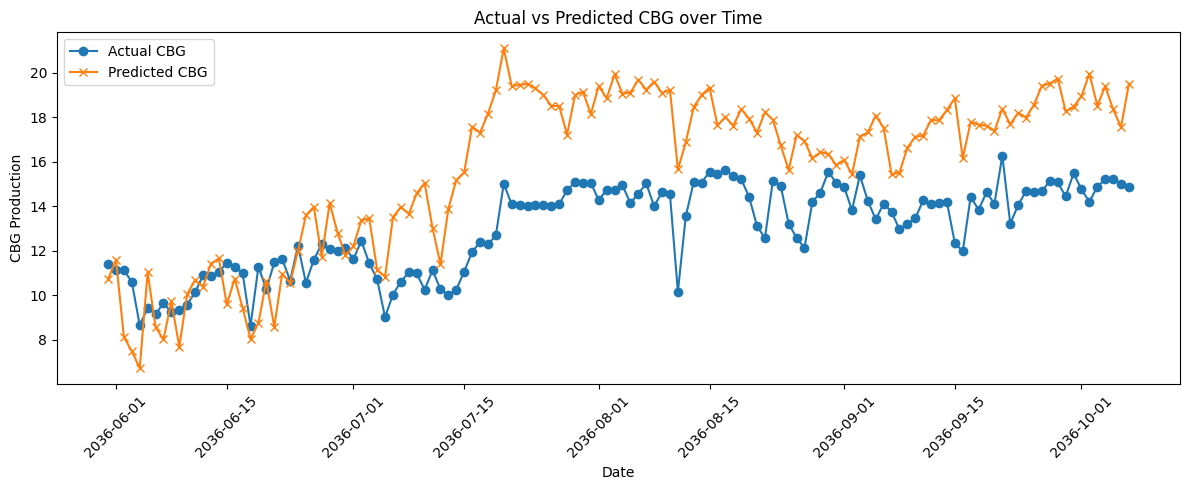

In [73]:
# assuming df is your original dataframe
# and y_test came from train_test_split

test_dates = input_data.loc[y_test.index, "Date"]

plt.figure(figsize=(12,5))
plt.plot(test_dates, y_test, label="Actual CBG", marker="o")
plt.plot(test_dates, y_pred, label="Predicted CBG", marker="x")

plt.xlabel("Date")
plt.ylabel("CBG Production")
plt.title("Actual vs Predicted CBG over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
print("Model input shape:", model.input_shape)

Model input shape: (None, 24)


In [75]:
from datetime import timedelta

N_DAYS = 7

FEATURE_COLS = [
    # Feed & composition
    "Feed TPD - PS",
    "PS - TS %",
    "PS - VS %",
    "Feed TPD - PMC",
    "PMC - TS %",
    "PMC - VS %",
    "Feed TPD - CD",
    "CD - TS %",
    "CD - VS %",

    # Totals
    "Total_Feed_TPD",
    "Total_VS_TPD",

    # Lag features (calculated)
    "Feed_TPD_Lag_1",
    "Feed_TPD_Lag_3",
    "Feed_TPD_Lag_7",

    # Rolling features (calculated)
    "Rolling_Avg_Feed_7D",
    "Rolling_Avg_VS_7D",

    # Process parameters
    "Hydrolyser Temp - Avg",
    "Digester Temp - Avg",
    "HRT",
    "VFA",
    "OLR",

    # NEW FEATURES
    "Raw biogas production (Nm³/day)",
    "Slurry fed into the digester (Nm3)",
    "Slurry fed out of the digester (Nm3)",
]

input_data = input_data.fillna(method="ffill")
input_data = input_data.fillna(method="bfill")

df = input_data.sort_values("Date").reset_index(drop=True)

last_date = pd.to_datetime(df.iloc[-1]["Date"])

# Feed & VS history (used for lag + rolling)
feed_history = list(df["Total_Feed_TPD"].tail(7))
vs_history = list(df["Total_VS_TPD"].tail(7))


future_rows = []

for day in range(1, N_DAYS + 1):

    future_date = last_date + timedelta(days=day)

    row = {}

    # ----------------------------
    # 1. Stable features (copied)
    # ----------------------------
    for col in FEATURE_COLS:
        if col not in [
            "Feed_TPD_Lag_1",
            "Feed_TPD_Lag_3",
            "Feed_TPD_Lag_7",
            "Rolling_Avg_Feed_7D",
            "Rolling_Avg_VS_7D",
        ]:
            row[col] = df.iloc[-1][col]

    # ----------------------------
    # 2. Lag features (calculated)
    # ----------------------------
    row["Feed_TPD_Lag_1"] = feed_history[-1]
    row["Feed_TPD_Lag_3"] = np.mean(feed_history[-3:])
    row["Feed_TPD_Lag_7"] = np.mean(feed_history[-7:])

    # ----------------------------
    # 3. Rolling averages
    # ----------------------------
    row["Rolling_Avg_Feed_7D"] = np.mean(feed_history)
    row["Rolling_Avg_VS_7D"] = np.mean(vs_history)

    # ----------------------------
    # 4. Create dataframe for ANN
    # ----------------------------
    X_future = pd.DataFrame([row])[FEATURE_COLS]
    X_future = X_future.astype(float)

    # Scale
    X_future_scaled = scaler.transform(X_future)
    X_future_scaled = np.array(X_future_scaled, dtype=np.float32)

    # ----------------------------
    # 5. Predict CBG
    # ----------------------------
    cbg_pred = model.predict(X_future_scaled, verbose=0)[0][0]

    # ----------------------------
    # 6. Store result
    # ----------------------------
    row["Date"] = future_date
    row["Predicted_CBG_kg_day"] = cbg_pred

    future_rows.append(row)

    # ----------------------------
    # 7. Update buffers (recursive!)
    # ----------------------------
    feed_history.append(row["Total_Feed_TPD"])
    vs_history.append(row["Total_VS_TPD"])

    feed_history = feed_history[-7:]
    vs_history = vs_history[-7:]

forecast_df = pd.DataFrame(future_rows)

forecast_df["Cumulative_CBG_kg"] = forecast_df["Predicted_CBG_kg_day"].cumsum()
forecast_df["CBG_kg_per_Ton_VS"] = (
    forecast_df["Predicted_CBG_kg_day"] / forecast_df["Total_VS_TPD"]
)

print(
    forecast_df[
        ["Date", "Predicted_CBG_kg_day"]
    ]
)

/tmp/ipython-input-269/866805806.py:43: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  input_data = input_data.fillna(method="ffill")
/tmp/ipython-input-269/866805806.py:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  input_data = input_data.fillna(method="bfill")


        Date  Predicted_CBG_kg_day
0 2036-10-08             19.728176
1 2036-10-09             19.980593
2 2036-10-10             20.408894
3 2036-10-11             20.697285
4 2036-10-12             20.965857
5 2036-10-13             21.168276
6 2036-10-14             21.563141


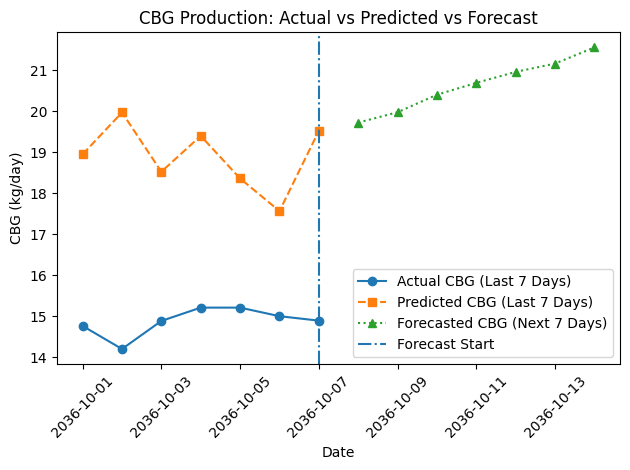

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
df["Date"] = pd.to_datetime(df["Date"])
forecast_df["Date"] = pd.to_datetime(forecast_df["Date"])

TARGET_COL = "CBG Production (kg/day)"  # change if your actual column name differs

# Last 7 actual days
last_7_actual = input_data.tail(7)[["Date", TARGET_COL]].copy()

# Last 7 predicted (aligning with last 7 rows)
last_7_pred = pd.DataFrame({
    "Date": last_7_actual["Date"].values,
    "Predicted_CBG": y_pred[-7:].flatten()
})

next_7_forecast = forecast_df.head(7)[
    ["Date", "Predicted_CBG_kg_day"]
].rename(columns={"Predicted_CBG_kg_day": "Forecasted_CBG"})


plt.figure()

# Actual CBG (last 7 days)
plt.plot(
    last_7_actual["Date"],
    last_7_actual[TARGET_COL],
    marker="o",
    label="Actual CBG (Last 7 Days)"
)

# Predicted CBG (last 7 days)
plt.plot(
    last_7_pred["Date"],
    last_7_pred["Predicted_CBG"],
    marker="s",
    linestyle="--",
    label="Predicted CBG (Last 7 Days)"
)

# Forecasted CBG (next 7 days)
plt.plot(
    next_7_forecast["Date"],
    next_7_forecast["Forecasted_CBG"],
    marker="^",
    linestyle=":",
    label="Forecasted CBG (Next 7 Days)"
)

# Vertical line to separate history & forecast
plt.axvline(
    x=last_7_actual["Date"].iloc[-1],
    linestyle="dashdot",
    label="Forecast Start"
)

plt.xlabel("Date")
plt.ylabel("CBG (kg/day)")
plt.title("CBG Production: Actual vs Predicted vs Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

✅ Prophet training shape: (646, 10)


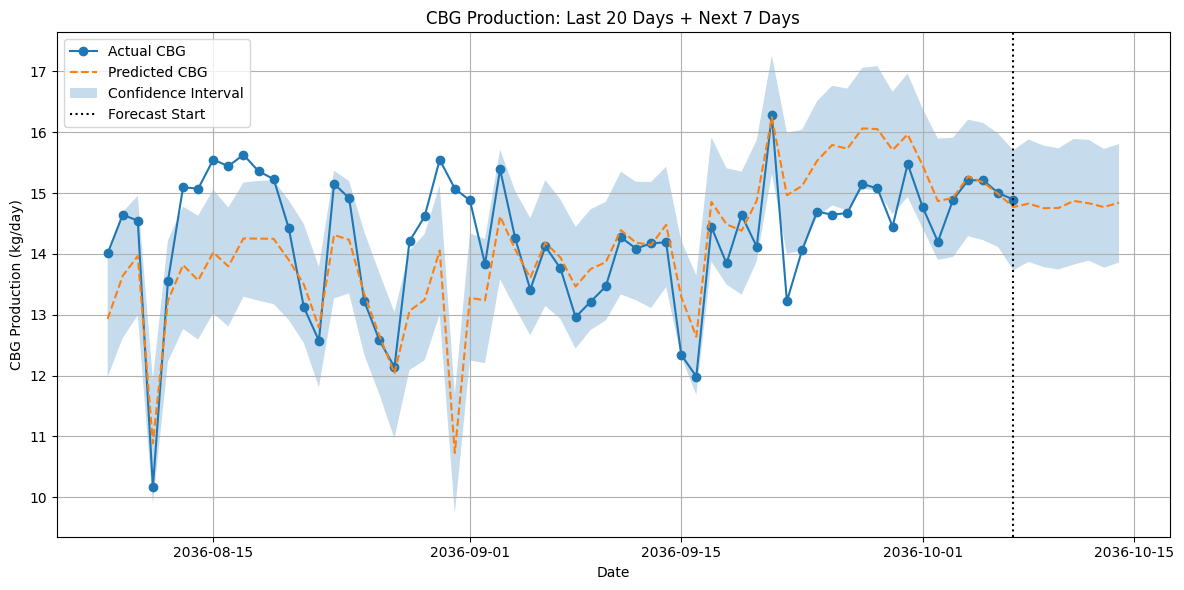

In [79]:
# ================================
# CBG FUTURE FORECAST USING PROPHET
# ================================

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# --------------------------------
# 1. LOAD / COPY DATA
# --------------------------------
df = input_for_prohet_model.copy()

# Clean column names
df.columns = df.columns.str.strip()

# --------------------------------
# 2. DATE + TARGET (PROPHET FORMAT)
# --------------------------------
df["ds"] = pd.to_datetime(df["Date"])
df["y"] = df["CBG Production (kg/day)"]

df = df.sort_values("ds").reset_index(drop=True)

# --------------------------------
# 3. FEATURE ENGINEERING
# --------------------------------

# ---- TOTAL FEED (TPD)
df["Total Feed TPD"] = (
    df["Feed TPD - PS"] +
    df["Feed TPD - PMC"] +
    df["Feed TPD - CD"]
)

# ---- TOTAL VS (TPD)
df["VS_PS"]  = df["Feed TPD - PS"]  * df["PS - TS %"]  / 100 * df["PS - VS %"]  / 100
df["VS_PMC"] = df["Feed TPD - PMC"] * df["PMC - TS %"] / 100 * df["PMC - VS %"] / 100
df["VS_CD"]  = df["Feed TPD - CD"]  * df["CD - TS %"]  / 100 * df["CD - VS %"]  / 100

df["Total VS TPD"] = df["VS_PS"] + df["VS_PMC"] + df["VS_CD"]

# ---- FIX UNIT / NAME MISMATCHES
df["Raw biogas production (Nm3/day)"] = df["Raw biogas production (Nm³/day)"]
df["Slurry fed into digester (Nm3)"] = df["Slurry fed into the digester (Nm3)"]
df["Slurry fed out of digester (Nm3)"] = df["Slurry fed out of the digester (Nm3)"]

# --------------------------------
# 4. REGRESSORS
# --------------------------------
regressors = [
    "Total Feed TPD",
    "Total VS TPD",
    "OLR",
    "HRT",
    "VFA",
    "Raw biogas production (Nm3/day)",
    "Slurry fed into digester (Nm3)",
    "Slurry fed out of digester (Nm3)"
]

# --------------------------------
# 5. FINAL MODEL DATA
# --------------------------------
df_model = df[["ds", "y"] + regressors].dropna()

print("✅ Prophet training shape:", df_model.shape)

# --------------------------------
# 6. INITIALIZE PROPHET
# --------------------------------
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    interval_width=0.90
)

for reg in regressors:
    model.add_regressor(reg)

# --------------------------------
# 7. FIT MODEL
# --------------------------------
model.fit(df_model)

import matplotlib.pyplot as plt

# --------------------------------
# 1. DEFINE WINDOW
# --------------------------------
LAST_N_DAYS = 60
FUTURE_DAYS = 7

last_date = df_model["ds"].max()
start_date = last_date - pd.Timedelta(days=LAST_N_DAYS)

# --------------------------------
# 2. FILTER FORECAST WINDOW
# --------------------------------
plot_df = forecast[
    (forecast["ds"] >= start_date) &
    (forecast["ds"] <= last_date + pd.Timedelta(days=FUTURE_DAYS))
]

# --------------------------------
# 3. ACTUAL VALUES (LAST 20 DAYS)
# --------------------------------
actual_df = df_model[df_model["ds"] >= start_date]

# --------------------------------
# 4. PLOT
# --------------------------------
plt.figure(figsize=(12, 6))

# Actual
plt.plot(
    actual_df["ds"],
    actual_df["y"],
    label="Actual CBG",
    marker="o"
)

# Forecast
plt.plot(
    plot_df["ds"],
    plot_df["yhat"],
    label="Predicted CBG",
    linestyle="--"
)

# Confidence interval
plt.fill_between(
    plot_df["ds"],
    plot_df["yhat_lower"],
    plot_df["yhat_upper"],
    alpha=0.25,
    label="Confidence Interval"
)

# Vertical line separating history & future
plt.axvline(last_date, color="black", linestyle=":", label="Forecast Start")

plt.title("CBG Production: Last 20 Days + Next 7 Days")
plt.xlabel("Date")
plt.ylabel("CBG Production (kg/day)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()